In [25]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI

In [26]:
class MessageState(TypedDict):
    user_input: str
    summary: str
    keywords: list
    sentiment: str


In [27]:
model = ChatOpenAI()

In [48]:
def sentiment_analysis(state: MessageState) -> MessageState:
    prompt = f"Tell sentiment of this text:\n{state['user_input']}"
    model_output = model.invoke(prompt).content
    return {"sentiment" : model_output}


def give_summary(state: MessageState) -> MessageState:
    prompt = f"Summarize this text:\n{state['user_input']}"
    return {"summary": model.invoke(prompt).content}


def extract_keyword(state: MessageState) -> MessageState:
    prompt = f"Extract keywords:\n{state['user_input']}"
    return {"keywords": model.invoke(prompt).content.split(",")}


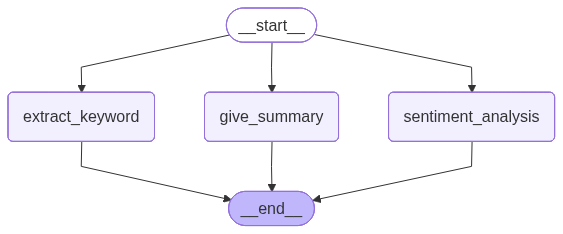

In [49]:
graph = StateGraph(MessageState)

graph.add_node("sentiment_analysis", sentiment_analysis)
graph.add_node("give_summary", give_summary)
graph.add_node("extract_keyword", extract_keyword)

graph.add_edge(START, "sentiment_analysis")
graph.add_edge(START, "give_summary")
graph.add_edge(START, "extract_keyword")

graph.add_edge("sentiment_analysis", END)
graph.add_edge("give_summary", END)
graph.add_edge("extract_keyword", END)

graph.compile()

In [50]:
workflow = graph.compile()

In [52]:
workflow.invoke({"user_input":"Python is a popular programming language used in AI, web development, automation, and data science."})

{'user_input': 'Python is a popular programming language used in AI, web development, automation, and data science.',
 'summary': 'Python is a versatile programming language popularly used in various fields such as AI, web development, automation, and data science.',
 'keywords': ['Python',
  ' programming language',
  ' AI',
  ' web development',
  ' automation',
  ' data science'],
 'sentiment': 'Positive sentiment.'}